In [ ]:
!pip install pandas nltk textblob matplotlib seaborn


In [ ]:
!pip install pandas tensorflow scikit-learn nltk

import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [ ]:
# Download stopwords from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Stats_EAS508/synthetic_social_media_data.csv')
# Display the first few rows
df.head()


,Post ID,Post Content,Sentiment Label,Number of Likes,Number of Shares,Number of Comments,User Follower Count,Post Date and Time,Post Type,Language
0,aa391375-7355-44b7-bcbf-97fb4e5a2ba3,Word who nor center everything better politica...,Neutral,157,243,64,4921,2024-01-10 00:14:21,video,fr
1,1c9ec98d-437a-48d9-9cba-bd5ad853c59a,Begin administration population good president...,Positive,166,49,121,612,2024-02-03 00:20:11,image,es
2,170e5b5b-1d9a-4d02-a957-93c4dbb18908,Thousand total sign. Agree product relationshi...,Positive,185,224,179,9441,2024-07-25 14:20:23,video,de
3,aec53496-60ee-4a06-8821-093a04dc8770,Individual from news third. Oil forget them di...,Neutral,851,369,39,6251,2024-02-20 09:15:09,text,de
4,4eacddb7-990d-4056-8784-7e1d5c4d1404,Time adult letter see reduce. Attention sudden...,Negative,709,356,52,1285,2024-03-01 04:17:35,image,de


In [ ]:
print(df.columns)


Index(['Post ID', 'Post Content', 'Sentiment Label', 'Number of Likes',
       'Number of Shares', 'Number of Comments', 'User Follower Count',
       'Post Date and Time', 'Post Type', 'Language'],
      dtype='object')


In [ ]:
# Display the first few rows of the dataset
print(df.head())

# Check the columns
print(df.columns)

# Get a summary of the dataset
print(df.info())


                                Post ID  \
0  aa391375-7355-44b7-bcbf-97fb4e5a2ba3   
1  1c9ec98d-437a-48d9-9cba-bd5ad853c59a   
2  170e5b5b-1d9a-4d02-a957-93c4dbb18908   
3  aec53496-60ee-4a06-8821-093a04dc8770   
4  4eacddb7-990d-4056-8784-7e1d5c4d1404   

                                        Post Content Sentiment Label  \
0  Word who nor center everything better politica...         Neutral   
1  Begin administration population good president...        Positive   
2  Thousand total sign. Agree product relationshi...        Positive   
3  Individual from news third. Oil forget them di...         Neutral   
4  Time adult letter see reduce. Attention sudden...        Negative   

   Number of Likes  Number of Shares  Number of Comments  User Follower Count  \
0              157               243                  64                 4921   
1              166                49                 121                  612   
2              185               224                 179         

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Check for null values
print(df.isnull().sum())

# Optionally, drop rows with missing Post Content or Sentiment Label
df.dropna(subset=['Post Content', 'Sentiment Label'], inplace=True)

# Convert 'Post Date and Time' to datetime
df['Post Date and Time'] = pd.to_datetime(df['Post Date and Time'])

# Display cleaned data
print(df.info())



Post ID                0
Post Content           0
Sentiment Label        0
Number of Likes        0
Number of Shares       0
Number of Comments     0
User Follower Count    0
Post Date and Time     0
Post Type              0
Language               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Post ID              2000 non-null   object        
 1   Post Content         2000 non-null   object        
 2   Sentiment Label      2000 non-null   object        
 3   Number of Likes      2000 non-null   int64         
 4   Number of Shares     2000 non-null   int64         
 5   Number of Comments   2000 non-null   int64         
 6   User Follower Count  2000 non-null   int64         
 7   Post Date and Time   2000 non-null   datetime64[ns]
 8   Post Type            2000 non-null   object        
 9 

In [ ]:
import re

def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove user mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation
    return text


In [ ]:
# Apply preprocessing to the content column
df['cleaned_content'] = df['Post Content'].apply(preprocess_text)

# Splitting the dataset
X = df['cleaned_content']
y = df['Sentiment Label']

In [ ]:
# Convert sentiment labels to numerical values if they are not already
# Assuming 'positive', 'negative', 'neutral' sentiments
label_mapping = {'positive': 2, 'neutral': 1, 'negative': 0}
y = y.map(label_mapping)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Text Tokenization and Padding
max_words = 10000       # Vocabulary size
max_len = 100           # Max length of each padded sequence

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


In [ ]:
print("Original y_train:", y_train)
print("Original y_test:", y_test)


Original y_train: []
Original y_test: []


In [ ]:
print("NaNs in original y_train:", y_train.isna().sum())
print("NaNs in original y_test:", y_test.isna().sum())


AttributeError: 'numpy.ndarray' object has no attribute 'isna'

In [ ]:
print("NaNs in original y_train:", y_train.isna().sum())
print("NaNs in original y_test:", y_test.isna().sum())


AttributeError: 'numpy.ndarray' object has no attribute 'isna'

In [ ]:
print("NaNs in y_train before filtering:", y_train.isna().sum())
print("NaNs in y_test before filtering:", y_test.isna().sum())


NaNs in y_train before filtering: 0
NaNs in y_test before filtering: 0


In [ ]:
# Ensure y_train and y_test are numpy arrays for boolean indexing
y_train = np.array(y_train)
y_test = np.array(y_test)


In [ ]:
# Filter out NaNs from y_train
non_nan_indices_train = ~np.isnan(y_train)
X_train_pad = X_train_pad[non_nan_indices_train]
y_train = y_train[non_nan_indices_train]

# Print the shapes after filtering
print("Filtered X_train_pad shape:", X_train_pad.shape)
print("Filtered y_train shape:", y_train.shape)


Filtered X_train_pad shape: (0, 100)
Filtered y_train shape: (0,)


In [ ]:
# Filter out NaNs from y_test (if applicable)
non_nan_indices_test = ~np.isnan(y_test)
X_test_pad = X_test_pad[non_nan_indices_test]
y_test = y_test[non_nan_indices_test]

# Print the shapes after filtering
print("Filtered X_test_pad shape:", X_test_pad.shape)
print("Filtered y_test shape:", y_test.shape)


Filtered X_test_pad shape: (0, 100)
Filtered y_test shape: (0,)


In [ ]:
# Continue with model training if shapes are valid
if len(y_train) > 0 and len(y_test) > 0:
    history = model.fit(X_train_pad, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)
else:
    print("No valid training or test data available.")

No valid training or test data available.


In [ ]:
# Check for NaNs in labels
print("NaNs in y_train:", y_train.isnull().sum())
print("NaNs in y_test:", y_test.isnull().sum())

# Remove rows with NaNs in y_train or y_test if any are found
X_train = X_train[y_train.notnull()]
y_train = y_train[y_train.notnull()]
X_test = X_test[y_test.notnull()]
y_test = y_test[y_test.notnull()]


NaNs in y_train: 1600
NaNs in y_test: 400


In [ ]:
# Check the shapes of X_train_pad and y_train
print("X_train_pad shape:", X_train_pad.shape)
print("y_train shape:", y_train.shape)

# Verify y_train is not empty
if y_train.size == 0:
    print("y_train is empty. Please check data processing steps.")
else:
    # Proceed with training only if y_train has data
    history = model.fit(X_train_pad, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)


X_train_pad shape: (1600, 100)
y_train shape: (0,)
y_train is empty. Please check data processing steps.


In [ ]:
# Model Building with LSTM
embedding_dim = 100  # Dimension for word embedding

model = Sequential([
    Embedding(max_words, embedding_dim, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # Assuming 3 classes (positive, neutral, negative)
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model Training

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Model Training
batch_size = 32
epochs = 5

history = model.fit(X_train_pad, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 1440
'y' sizes: 0


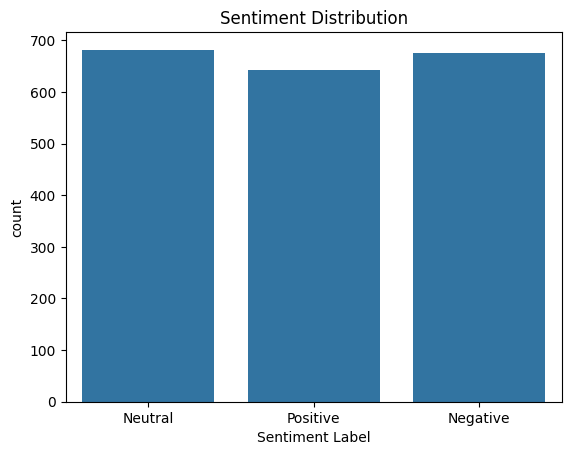

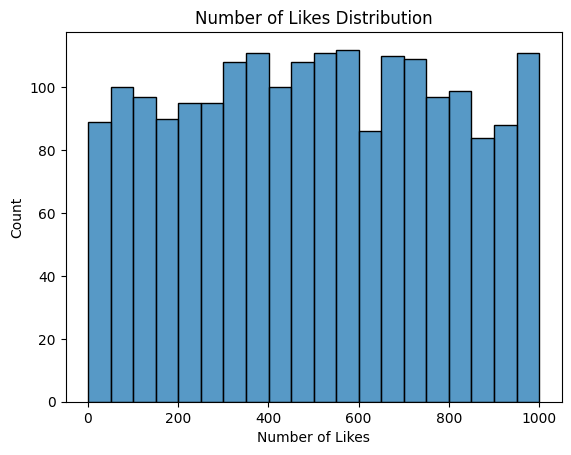

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the sentiment distribution
sns.countplot(x='Sentiment Label', data=df)
plt.title('Sentiment Distribution')
plt.show()

# Example: Visualize likes distribution
sns.histplot(df['Number of Likes'], bins=20)
plt.title('Number of Likes Distribution')
plt.show()


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Calculate sentiment scores for each comment
df['sentiment_score'] = df['cleaned_content'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Define sentiment categories based on score
df['calculated_sentiment'] = df['sentiment_score'].apply(lambda score: 'positive' if score >= 0.05 else ('negative' if score <= -0.05 else 'neutral'))


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
from sklearn.model_selection import train_test_split

# Define the features (X) and target (y)
X = df['cleaned_content']  # Features are the cleaned post contents
y = df['Sentiment Label']   # Target is the sentiment label

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 1600
Testing set size: 400


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to 5000 features for simplicity

# Fit the vectorizer on the training data and transform both train and test sets
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)


LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Display detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Display confusion matrix for further insights
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)


Accuracy: 0.355
Classification Report:
               precision    recall  f1-score   support

    Negative       0.34      0.45      0.38       121
     Neutral       0.40      0.36      0.38       149
    Positive       0.33      0.26      0.29       130

    accuracy                           0.35       400
   macro avg       0.35      0.36      0.35       400
weighted avg       0.36      0.35      0.35       400

Confusion Matrix:
 [[54 34 33]
 [58 54 37]
 [49 47 34]]


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# Initialize the VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Apply VADER to each comment
df['sentiment_score'] = df['cleaned_content'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Classify based on score
df['sentiment_class'] = df['sentiment_score'].apply(lambda score: 'positive' if score >= 0.05 else ('negative' if score <= -0.05 else 'neutral'))


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


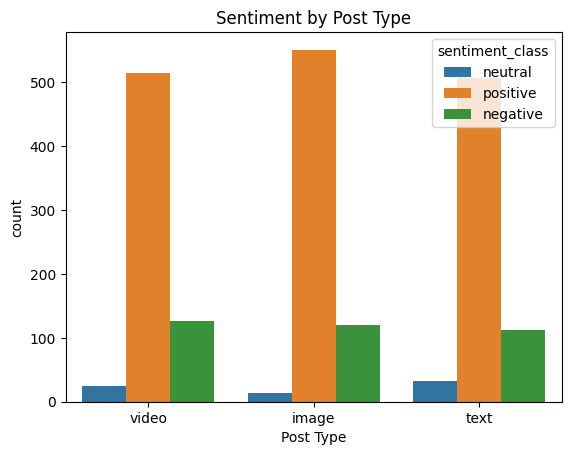

<ipython-input-14-137ed4f376ce>:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M')['sentiment_score'].mean().plot()


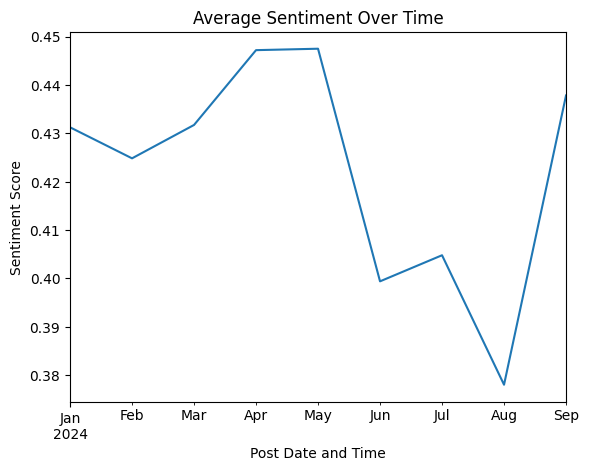

In [ ]:
# Visualize sentiment distribution by post type
sns.countplot(x='Post Type', hue='sentiment_class', data=df)
plt.title('Sentiment by Post Type')
plt.show()

# Example: Sentiment over time (if Post Date is available)
df['Post Date and Time'] = pd.to_datetime(df['Post Date and Time'])
df.set_index('Post Date and Time', inplace=True)

# Plot sentiment over time
df.resample('M')['sentiment_score'].mean().plot()
plt.title('Average Sentiment Over Time')
plt.ylabel('Sentiment Score')
plt.show()


In [ ]:
# Sentiment analysis function
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

# Apply sentiment analysis
df['sentiment_score'] = df['cleaned_comment'].apply(get_sentiment)

# Categorize sentiment
df['sentiment'] = df['sentiment_score'].apply(lambda score: 'positive' if score > 0 else ('negative' if score < 0 else 'neutral'))

# Display processed data
df[['comment', 'cleaned_comment', 'sentiment_score', 'sentiment']].head()


KeyError: 'cleaned_comment'

In [ ]:
df['cleaned_content'] = df['Post Content'].apply(preprocess_text)

# Step 5: Split the Dataset
X = df['cleaned_content']
y = df['Sentiment Label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


NameError: name 'train_test_split' is not defined

In [ ]:
from wordcloud import WordCloud

# Word cloud for positive comments
positive_comments = " ".join(df[df['sentiment'] == 'positive']['cleaned_comment'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_comments)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Positive Comments")
plt.show()
